In [1]:
import torch
import matplotlib.pyplot as plt 
from lorenz import Lorenz63, TimeAveragedFeatures

N = 500
T = 360
spinup = 30
dt = 0.01
params = {
    'sigma':10,
    'beta':8/3,
    'rho':28 
}
l63 = Lorenz63(**params)
x0 = torch.randn((N,3))
r = l63(x0,T,dt)
l63_avg = TimeAveragedFeatures(l63,spinup=spinup)

r_avg = l63_avg(x0,T,dt)


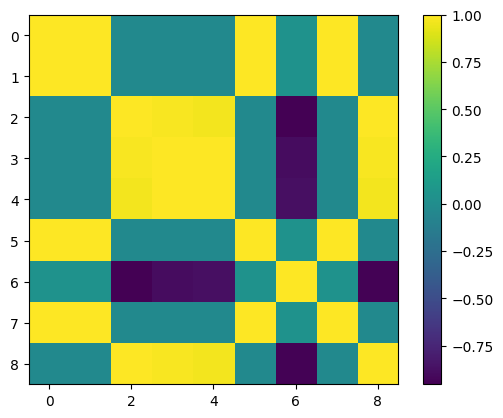

In [46]:
## get EOFs of r_avg 
r_avg_centered = (r_avg - r_avg.mean(dim=0))/r_avg.std(dim=0)
cov_matrix = torch.cov(r_avg_centered.T)
plt.imshow(cov_matrix.detach().numpy())
plt.colorbar()

In [ ]:
eigval,eigvec = torch.linalg.ei gh(cov_matrix)

In [54]:
eigval

tensor([6.7431e-07, 2.8464e-05, 1.3288e-04, 2.3982e-04, 3.4953e-03, 1.8261e-02,
        1.5588e-01, 3.9759e+00, 4.8461e+00], grad_fn=<LinalgEighBackward0>)

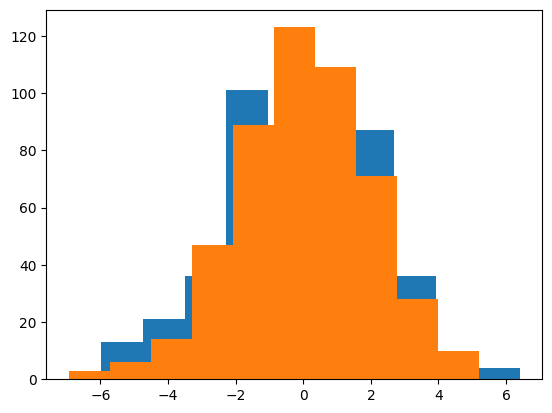

In [55]:
a1 = r_avg_centered @ eigvec[:,-1]
a2 = r_avg_centered @ eigvec[:,-2]
with torch.no_grad():
    plt.hist(r_avg_centered @ eigvec[:,-1],bins=10)
    plt.hist(r_avg_centered @ eigvec[:,-2],bins=10)

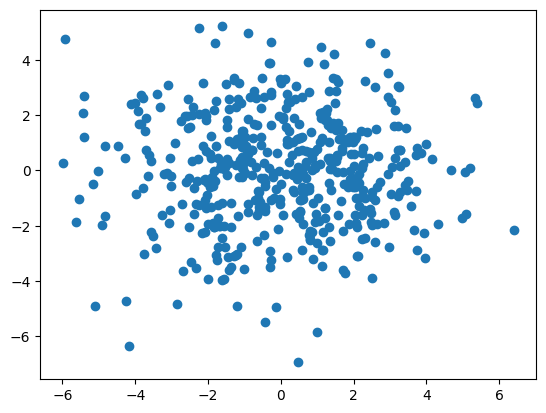

In [51]:
with torch.no_grad():
    plt.scatter(a1,a2)

In [35]:
from gpytorch.distributions import MultivariateNormal

mean = torch.tensor([a1.mean(),a2.mean()])
cov_var = torch.diag(torch.tensor([a1.var(),a2.var()]))
stats = MultivariateNormal(mean,cov_var)


In [44]:
from abracalibra.history_matching import HistoryMatchingBase
from abracalibra.forward_model import ForwardModel
from gpytorch.kernels import RBFKernel,ScaleKernel
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.distributions import MultitaskMultivariateNormal
from gpytorch.models import ExactGP 
from gpytorch.means import ConstantMean
from gpytorch.mlls import ExactMarginalLogLikelihood
from torch.distributions import Uniform

def lorenz63(sigma,beta,rho):
    with torch.no_grad():
        l = TimeAveragedFeatures(Lorenz63(sigma.clone(),beta.clone(),rho.clone()),spinup=spinup)
        fwd = l(x0,T,dt)
        a1 = torch.dot(fwd[0], eigvec[:,-1])
        a2 = torch.dot(fwd[0], eigvec[:,-2])
        return torch.tensor([a1,a2])
    

class LorenzGP(ExactGP):
    def __init__(self,train_x,train_y,likelihood):
        self.batch_shape = train_y.shape[-1]
        super(LorenzGP,self).__init__(train_x,train_y,likelihood)
        self.mean_module = ConstantMean(batch_shape=torch.Size([self.batch_shape]))
        self.covar_module = ScaleKernel(RBFKernel(batch_shape=torch.Size([self.batch_shape])),batch_shape=torch.Size([self.batch_shape]))

    def forward(self,x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultitaskMultivariateNormal.from_batch_mvn(MultivariateNormal(mean_x,covar_x))

class LorenzPCAHM(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)

        likelihood = MultitaskGaussianLikelihood(num_tasks=self.number_of_observables,has_global_noise=False)
        model = LorenzGP(parameters, observations, likelihood)  

        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model


parameters = ['beta','rho']
def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

priors = {
    # 'sigma':Uniform(9,11),
    'beta':Uniform(2,3),
    'rho':Uniform(25,30)
} # th
fwd = ForwardModel(lorenz63,vectorized=False,sigma=10)
hm = LorenzPCAHM(parameters,priors,stats,ensemble_size=50,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(1)


Step 0 Loss: 9974.943359375
Step 1 Loss: 9292.927734375
Step 2 Loss: 8671.0341796875
Step 3 Loss: 8104.4560546875
Step 4 Loss: 7588.57861328125
Step 5 Loss: 7118.98681640625
Step 6 Loss: 6691.5263671875
Step 7 Loss: 6302.30810546875
Step 8 Loss: 5947.7275390625
Step 9 Loss: 5624.458984375
Step 10 Loss: 5329.462890625
Step 11 Loss: 5059.9736328125
Step 12 Loss: 4813.48583984375
Step 13 Loss: 4587.7412109375
Step 14 Loss: 4380.70703125
Step 15 Loss: 4190.56201171875
Step 16 Loss: 4015.673828125
Step 17 Loss: 3854.580322265625
Step 18 Loss: 3705.975830078125
Step 19 Loss: 3568.686767578125
Step 20 Loss: 3441.66162109375
Step 21 Loss: 3323.9619140625
Step 22 Loss: 3214.739013671875
Step 23 Loss: 3113.234130859375
Step 24 Loss: 3018.763427734375
Step 25 Loss: 2930.709716796875
Step 26 Loss: 2848.52001953125
Step 27 Loss: 2771.693359375
Step 28 Loss: 2699.7783203125
Step 29 Loss: 2632.365966796875
Step 30 Loss: 2569.089111328125
Step 31 Loss: 2509.614013671875
Step 32 Loss: 2453.63671875
Ste

In [41]:
from gpytorch.settings import fast_pred_var
nroy,coords= hm.nroy_over_support(num_points=250,return_coords=True)
coords = hm.get_support_axis(0,250)
X,Y = torch.meshgrid(*coords,indexing='ij')


emulator = hm.emulators[0]
emulator.eval()


with fast_pred_var(), torch.no_grad():
    pred = emulator(torch.stack([X,Y],dim=-1).view(-1,2))
    imp = hm.implausibility(torch.stack([X,Y],dim=-1).view(-1,2),0)
    
pred_mean = pred.mean.view(250,250,2)
imp = imp.view(250,250)


torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True
torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [42]:
hm.implausibility(torch.tensor([params['beta'],params['rho']]).view(1,2),0)

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


tensor([6.9692], grad_fn=<ViewBackward0>)

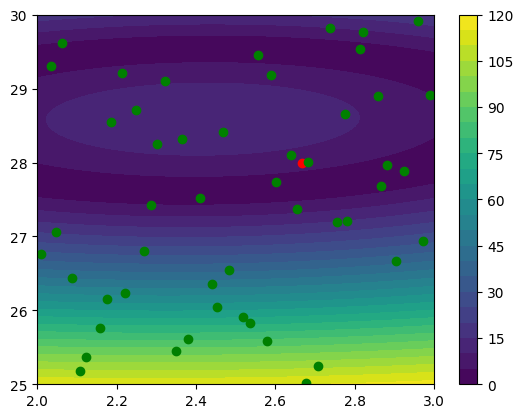

In [43]:
import matplotlib.pyplot as plt
plt.contourf(X,Y,imp,levels=25) 

plt.colorbar()
plt.scatter([params['beta']],[params['rho']],color='r')
plt.scatter(hm.params[0,:,0],hm.params[0,:,1],color='g')